<a href="https://colab.research.google.com/github/KunalSoyane/ML-Playground/blob/main/ML_Playground.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# ML PLAYGROUND — KUNAL SOYANE
# 5-algorithm exploration across classification, regression,
# clustering, NLP, and recommendation systems.
# Runtime: Google Colab (CPU sufficient for all cells)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import (load_breast_cancer, fetch_california_housing,
                               load_iris, fetch_20newsgroups)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingRegressor
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, mean_squared_error,
                              r2_score, silhouette_score)

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#f9f9f9',
    'axes.grid':         True,
    'grid.alpha':        0.3,
    'axes.spines.top':   False,
    'axes.spines.right': False,
})

print("Libraries loaded. Environment ready.")

Libraries loaded. Environment ready.


Dataset: Breast Cancer Wisconsin
  Samples  : 569
  Features : 30
  Classes  : [np.str_('malignant'), np.str_('benign')]
  Distribution: {np.str_('malignant'): np.int64(212), np.str_('benign'): np.int64(357)}

Test Accuracy : 0.9561  (95.61%)

Classification Report:
              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        42
      benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



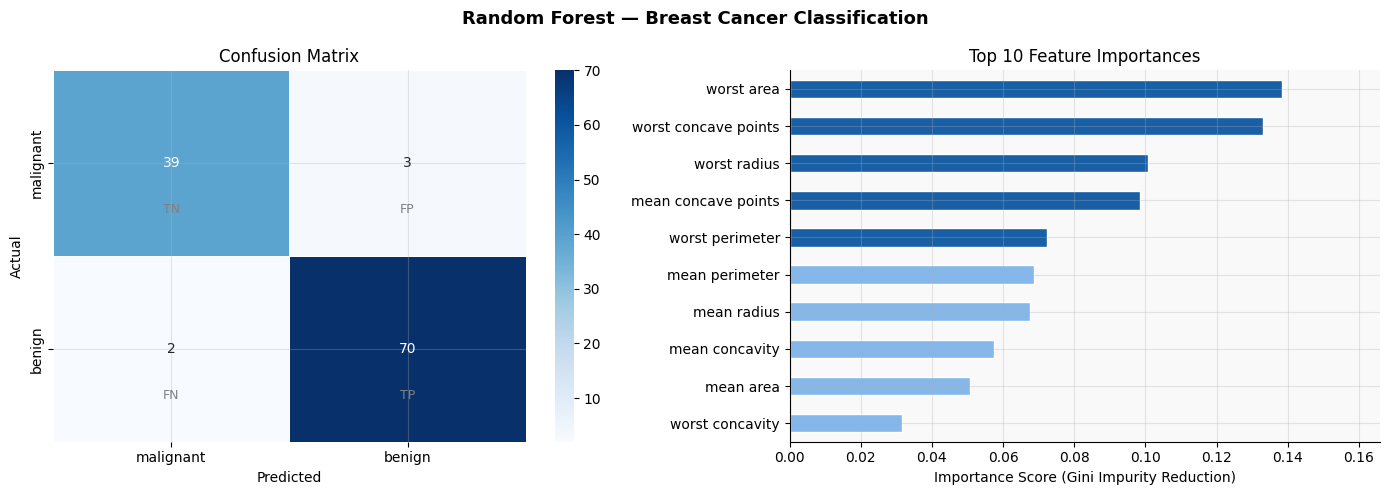

In [2]:
# ============================================================
# CELL 2 — RANDOM FOREST | CLASSIFICATION
# Dataset : Breast Cancer Wisconsin
# Task    : Binary classification — malignant vs benign
# ============================================================

data          = load_breast_cancer()
X, y          = data.data, data.target
feature_names = data.feature_names
target_names  = data.target_names   # ['malignant', 'benign']

print("Dataset: Breast Cancer Wisconsin")
print(f"  Samples  : {X.shape[0]}")
print(f"  Features : {X.shape[1]}")
print(f"  Classes  : {list(target_names)}")
print(f"  Distribution: {dict(zip(target_names, np.bincount(y)))}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# n_estimators : number of trees in the ensemble
# max_depth    : controls tree complexity; limits overfitting
rf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
acc    = accuracy_score(y_test, y_pred)

print(f"\nTest Accuracy : {acc:.4f}  ({acc * 100:.2f}%)")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=target_names))

# ── Visualisation ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Random Forest — Breast Cancer Classification",
             fontsize=13, fontweight='bold')

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names,
            ax=axes[0], linewidths=0.5, linecolor='white')
axes[0].set_title('Confusion Matrix')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

for i in range(2):
    for j in range(2):
        label = ['TN', 'FP', 'FN', 'TP'][i * 2 + j]
        axes[0].text(j + 0.5, i + 0.75, label,
                     ha='center', va='center', fontsize=9, color='gray')

# Top 10 feature importances
importances = pd.Series(rf.feature_importances_, index=feature_names).nlargest(10)
colors_imp  = ['#185FA5' if v > importances.median() else '#85B7EB'
               for v in importances]
importances.sort_values().plot(kind='barh', ax=axes[1],
                               color=colors_imp[::-1], edgecolor='white')
axes[1].set_title('Top 10 Feature Importances')
axes[1].set_xlabel('Importance Score (Gini Impurity Reduction)')
axes[1].set_xlim(0, importances.max() * 1.2)

plt.tight_layout()
plt.show()

# Notes:
# - Confusion matrix: rows = actual labels, columns = predicted labels
# - TP (true positive) = correctly identified malignant cases — highest priority
# - Feature importance = average reduction in Gini impurity across all trees

Dataset: California Housing
  Samples  : 20640
  Features : 8  ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
  Target   : Median house value (units: $100,000)

RMSE    : 0.5116  (avg. prediction error in $100K units)
R2 Score: 0.8003  (model explains 80.0% of price variance)


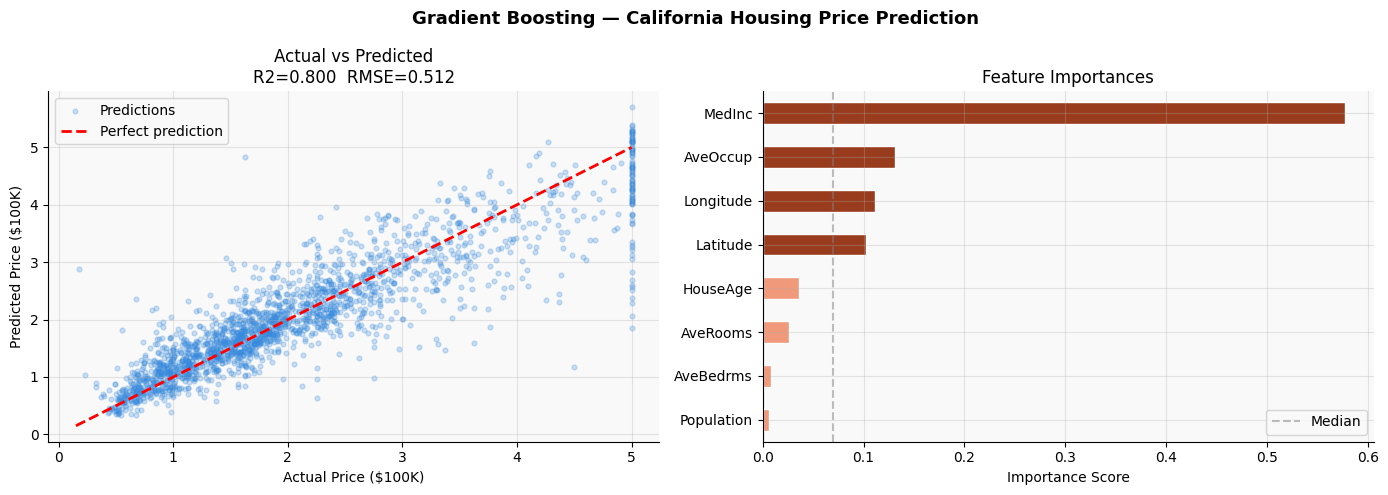

In [3]:
# ============================================================
# CELL 3 — GRADIENT BOOSTING | REGRESSION
# Dataset : California Housing (1990 census)
# Task    : Predict median house value
# ============================================================

housing       = fetch_california_housing()
X, y          = housing.data, housing.target
feature_names = housing.feature_names

print("Dataset: California Housing")
print(f"  Samples  : {X.shape[0]}")
print(f"  Features : {X.shape[1]}  {list(feature_names)}")
print(f"  Target   : Median house value (units: $100,000)")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# n_estimators  : number of sequential boosting rounds
# learning_rate : shrinkage — lower value reduces overfitting
# max_depth     : keep shallow (3-4) for weak learners
# subsample     : fraction of training data per tree (stochastic GBM)
gbm = GradientBoostingRegressor(
    n_estimators=200, learning_rate=0.1,
    max_depth=3, subsample=0.8, random_state=42
)
gbm.fit(X_train, y_train)

y_pred = gbm.predict(X_test)
rmse   = np.sqrt(mean_squared_error(y_test, y_pred))
r2     = r2_score(y_test, y_pred)

print(f"\nRMSE    : {rmse:.4f}  (avg. prediction error in $100K units)")
print(f"R2 Score: {r2:.4f}  (model explains {r2 * 100:.1f}% of price variance)")

# ── Visualisation ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Gradient Boosting — California Housing Price Prediction",
             fontsize=13, fontweight='bold')

# Actual vs predicted (sample 2000 points for plot clarity)
idx = np.random.choice(len(y_test), 2000, replace=False)
axes[0].scatter(y_test[idx], y_pred[idx],
                alpha=0.25, color='#378ADD', s=12, label='Predictions')
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             'r--', lw=2, label='Perfect prediction')
axes[0].set_xlabel('Actual Price ($100K)')
axes[0].set_ylabel('Predicted Price ($100K)')
axes[0].set_title(f'Actual vs Predicted\nR2={r2:.3f}  RMSE={rmse:.3f}')
axes[0].legend()

# Feature importances
importances = pd.Series(gbm.feature_importances_,
                        index=feature_names).sort_values()
colors_gbm  = ['#993C1D' if v > importances.median() else '#F0997B'
               for v in importances]
importances.plot(kind='barh', ax=axes[1], color=colors_gbm, edgecolor='white')
axes[1].set_title('Feature Importances')
axes[1].set_xlabel('Importance Score')
axes[1].axvline(importances.median(), color='gray',
                linestyle='--', alpha=0.5, label='Median')
axes[1].legend()

plt.tight_layout()
plt.show()

# Notes:
# - GBM builds trees sequentially; each tree corrects residual errors of the previous
# - MedInc (median income) consistently dominates feature importance in this dataset
# - R2 of 0.80+ indicates strong predictive signal despite geographic complexity

Dataset: Iris Flowers
  Samples   : 150
  Features  : ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
  True labels are withheld from the model — used only for post-hoc comparison

PCA variance retained:
  PC1: 73.0%   PC2: 22.9%
  Total: 95.8% of original information retained

KMeans (K=3):
  Inertia (WCSS)   : 139.8205
  Silhouette Score : 0.4599  (range: -1 to 1; higher = better separation)


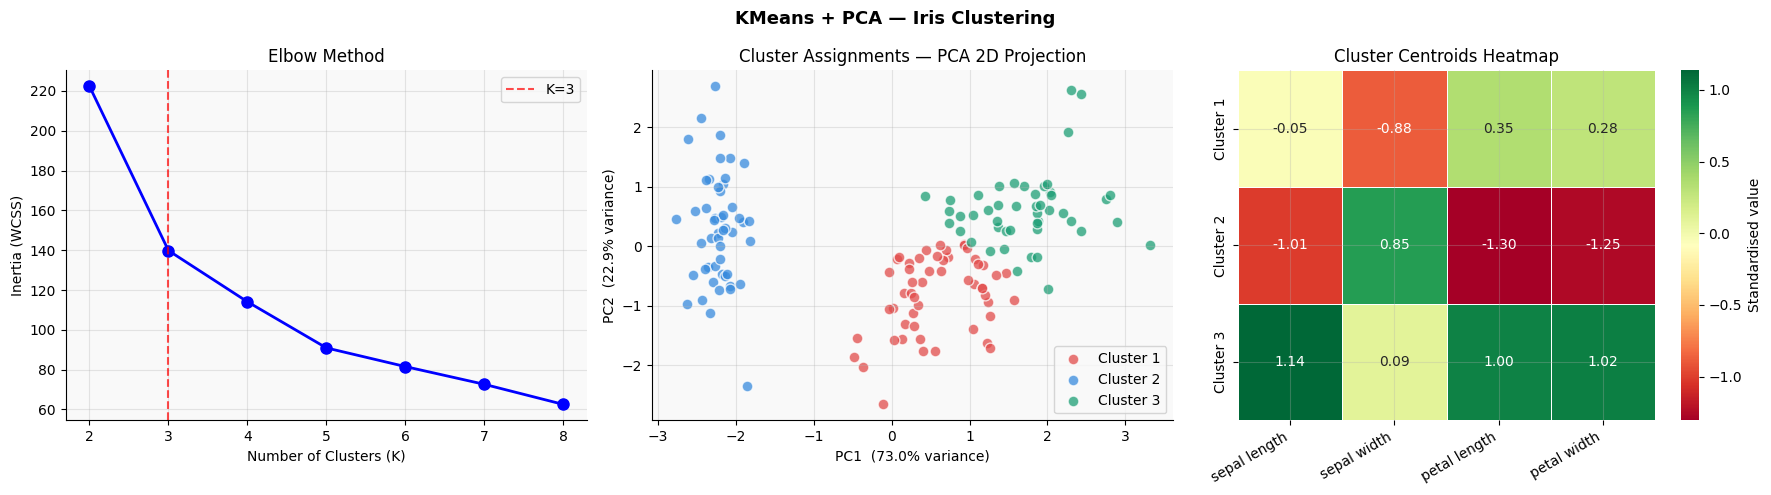

In [4]:
# ============================================================
# CELL 4 — KMEANS + PCA | CLUSTERING
# Dataset : Iris
# Task    : Unsupervised grouping — no labels used during fit
# ============================================================

iris          = load_iris()
X, y_true     = iris.data, iris.target
feature_names = iris.feature_names
target_names  = iris.target_names   # setosa, versicolor, virginica

print("Dataset: Iris Flowers")
print(f"  Samples   : {X.shape[0]}")
print(f"  Features  : {list(feature_names)}")
print(f"  True labels are withheld from the model — used only for post-hoc comparison")

# Standardise: KMeans is distance-based; unscaled features skew cluster assignments
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Elbow method: identify K where inertia reduction becomes marginal
inertias   = []
sil_scores = []
K_range    = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, km.labels_))

# PCA: reduce 4D to 2D for visualisation while retaining maximum variance
pca           = PCA(n_components=2)
X_pca         = pca.fit_transform(X_scaled)
var_explained = pca.explained_variance_ratio_

print(f"\nPCA variance retained:")
print(f"  PC1: {var_explained[0] * 100:.1f}%   PC2: {var_explained[1] * 100:.1f}%")
print(f"  Total: {var_explained.sum() * 100:.1f}% of original information retained")

# Final KMeans with K=3 (confirmed by elbow + domain knowledge of 3 species)
km             = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_labels = km.fit_predict(X_scaled)
sil            = silhouette_score(X_scaled, cluster_labels)

print(f"\nKMeans (K=3):")
print(f"  Inertia (WCSS)   : {km.inertia_:.4f}")
print(f"  Silhouette Score : {sil:.4f}  (range: -1 to 1; higher = better separation)")

# ── Visualisation ─────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("KMeans + PCA — Iris Clustering",
             fontsize=13, fontweight='bold')

# Elbow curve
axes[0].plot(list(K_range), inertias, 'bo-', markersize=8, linewidth=2)
axes[0].axvline(x=3, color='red', linestyle='--', alpha=0.7, label='K=3')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia (WCSS)')
axes[0].set_title('Elbow Method')
axes[0].legend()
axes[0].set_xticks(list(K_range))

# PCA scatter coloured by cluster assignment
CLUSTER_COLORS = ['#E24B4A', '#378ADD', '#1D9E75']
for i, color in enumerate(CLUSTER_COLORS):
    mask = cluster_labels == i
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=color, label=f'Cluster {i + 1}',
                    alpha=0.75, s=60, edgecolors='white')
axes[1].set_xlabel(f'PC1  ({var_explained[0] * 100:.1f}% variance)')
axes[1].set_ylabel(f'PC2  ({var_explained[1] * 100:.1f}% variance)')
axes[1].set_title('Cluster Assignments — PCA 2D Projection')
axes[1].legend()

# Centroid heatmap: shows the mean feature value per cluster
centroids_df = pd.DataFrame(
    km.cluster_centers_,
    columns=[f.replace(' (cm)', '') for f in feature_names],
    index=[f'Cluster {i + 1}' for i in range(3)]
)
sns.heatmap(centroids_df, annot=True, fmt='.2f', cmap='RdYlGn',
            ax=axes[2], linewidths=0.5,
            cbar_kws={'label': 'Standardised value'})
axes[2].set_title('Cluster Centroids Heatmap')
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.show()

# Notes:
# - Standardisation is mandatory before KMeans; distance metrics are scale-sensitive
# - Centroid heatmap is more informative than the scatter plot for interpreting clusters
# - Cluster 3 (high petal dimensions) maps closely to virginica in the true labels

Fetching 20 Newsgroups dataset (~15MB, downloaded once)...
  Training samples : 1775
  Test samples     : 1182
  Categories       : ['Medicine', 'Baseball', 'Graphics']

TF-IDF matrix shape: (1775, 5000)  (documents x vocabulary)

Test Accuracy : 0.9162  (91.62%)

Classification Report:
              precision    recall  f1-score   support

    Medicine       0.91      0.93      0.92       389
    Baseball       0.89      0.95      0.92       397
    Graphics       0.96      0.87      0.91       396

    accuracy                           0.92      1182
   macro avg       0.92      0.92      0.92      1182
weighted avg       0.92      0.92      0.92      1182



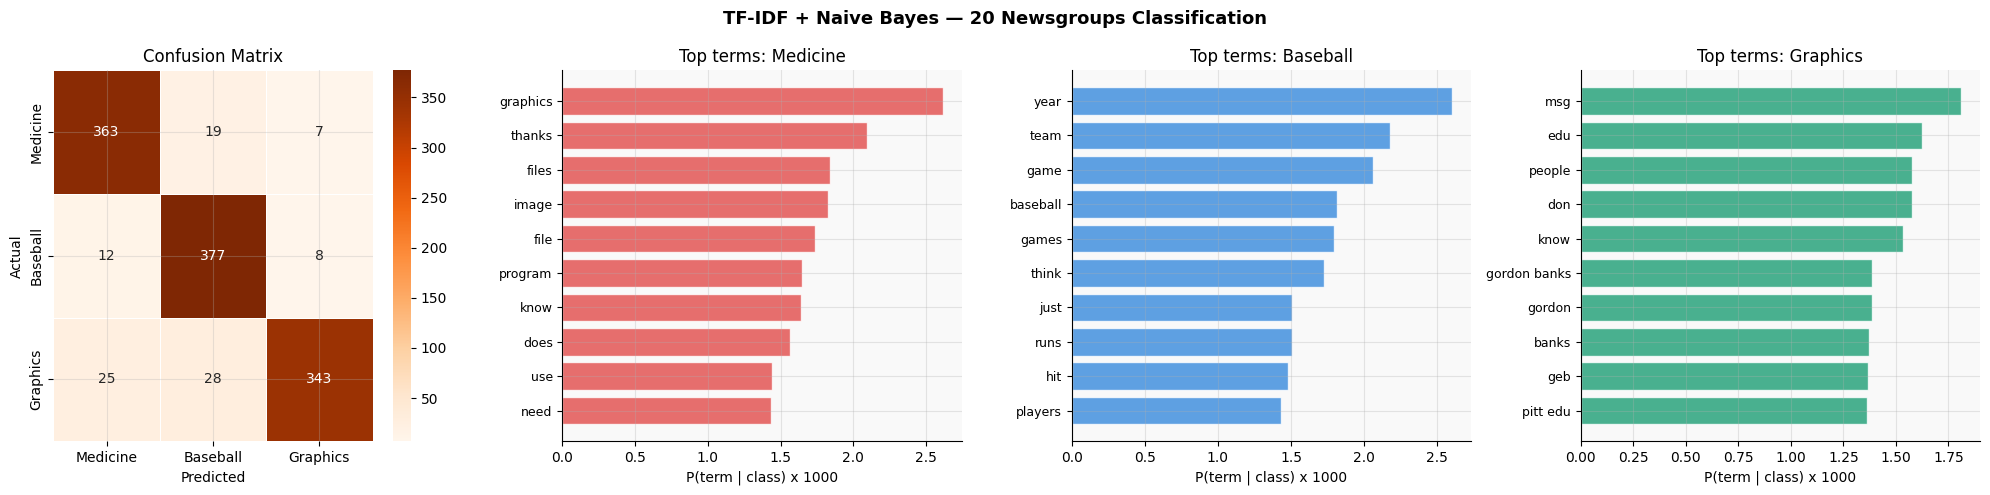


Inference on custom inputs:
  [Graphics    90.5%]  The patient was diagnosed with a rare bone marrow disease
  [Baseball    84.1%]  The pitcher threw a fastball in the ninth inning
  [Medicine    86.1%]  The GPU renders 3D models with ray tracing


In [5]:
# ============================================================
# CELL 5 — TF-IDF + NAIVE BAYES | TEXT CLASSIFICATION
# Dataset : 20 Newsgroups (3 categories)
# Task    : Multi-class document classification
# ============================================================

CATEGORIES  = ['sci.med', 'rec.sport.baseball', 'comp.graphics']
SHORT_NAMES = ['Medicine', 'Baseball', 'Graphics']

print("Fetching 20 Newsgroups dataset (~15MB, downloaded once)...")

train_data = fetch_20newsgroups(subset='train', categories=CATEGORIES,
                                remove=('headers', 'footers', 'quotes'))
test_data  = fetch_20newsgroups(subset='test',  categories=CATEGORIES,
                                remove=('headers', 'footers', 'quotes'))

print(f"  Training samples : {len(train_data.data)}")
print(f"  Test samples     : {len(test_data.data)}")
print(f"  Categories       : {SHORT_NAMES}")

# TF-IDF vectorisation
# max_features : vocabulary cap — keeps top 5000 terms by corpus TF-IDF weight
# stop_words   : removes high-frequency, low-information function words
# ngram_range  : unigrams + bigrams capture short phrases ('bone marrow', 'home run')
tfidf = TfidfVectorizer(max_features=5000, stop_words='english', ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(train_data.data)
X_test_tfidf  = tfidf.transform(test_data.data)

print(f"\nTF-IDF matrix shape: {X_train_tfidf.shape}  (documents x vocabulary)")

# Multinomial Naive Bayes
# alpha=1.0 : Laplace smoothing — prevents zero probability for unseen vocabulary
nb = MultinomialNB(alpha=1.0)
nb.fit(X_train_tfidf, train_data.target)

y_pred = nb.predict(X_test_tfidf)
acc    = accuracy_score(test_data.target, y_pred)

print(f"\nTest Accuracy : {acc:.4f}  ({acc * 100:.2f}%)")
print("\nClassification Report:")
print(classification_report(test_data.target, y_pred, target_names=SHORT_NAMES))

# ── Visualisation ─────────────────────────────────────────
feature_arr = np.array(tfidf.get_feature_names_out())
TOP_N       = 10
NLP_COLORS  = ['#E24B4A', '#378ADD', '#1D9E75']

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle("TF-IDF + Naive Bayes — 20 Newsgroups Classification",
             fontsize=13, fontweight='bold')

cm = confusion_matrix(test_data.target, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=SHORT_NAMES, yticklabels=SHORT_NAMES,
            ax=axes[0], linewidths=0.5, linecolor='white')
axes[0].set_title('Confusion Matrix')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# Top discriminative terms per class (by log-probability under the model)
for i, (ax, name, color) in enumerate(zip(axes[1:], SHORT_NAMES, NLP_COLORS)):
    top_idx   = np.argsort(nb.feature_log_prob_[i])[-TOP_N:][::-1]
    top_words = feature_arr[top_idx]
    top_probs = np.exp(nb.feature_log_prob_[i][top_idx])

    ax.barh(range(TOP_N), top_probs[::-1] * 1000,
            color=color, alpha=0.8, edgecolor='white')
    ax.set_yticks(range(TOP_N))
    ax.set_yticklabels(top_words[::-1], fontsize=9)
    ax.set_title(f'Top terms: {name}')
    ax.set_xlabel('P(term | class) x 1000')

plt.tight_layout()
plt.show()

# Inference on held-out sentences
test_sentences = [
    "The patient was diagnosed with a rare bone marrow disease",
    "The pitcher threw a fastball in the ninth inning",
    "The GPU renders 3D models with ray tracing",
]

print("\nInference on custom inputs:")
for sentence in test_sentences:
    vec  = tfidf.transform([sentence])
    pred = nb.predict(vec)[0]
    prob = nb.predict_proba(vec)[0]
    print(f"  [{SHORT_NAMES[pred]:10s}  {prob.max() * 100:.1f}%]  {sentence}")

# Notes:
# - Removing headers/footers/quotes is critical; they leak category identity
# - TF-IDF down-weights terms frequent across all documents (low discriminative value)
# - Top-term charts reveal the learned 'vocabulary signature' of each class

Ratings matrix: 12 users x 15 movies
Sparsity: 62.8% of entries unrated (the problem we solve)

SVD latent factors : 5
Variance explained : 85.1%

Top recommendations per user:

  User_1  (liked genres: ['Action', 'Thriller'])
    The Avengers            [Action    ]  predicted rating: 2.29/5
    La La Land              [Romance   ]  predicted rating: 0.83/5
    Inception               [SciFi     ]  predicted rating: 0.35/5

  User_4  (liked genres: ['SciFi'])
    The Matrix              [SciFi     ]  predicted rating: 1.90/5
    Notebook                [Romance   ]  predicted rating: 0.86/5
    Gone Girl               [Thriller  ]  predicted rating: 0.78/5

  User_7  (liked genres: ['Romance'])
    Inception               [SciFi     ]  predicted rating: 0.75/5
    The Avengers            [Action    ]  predicted rating: 0.41/5
    The Godfather           [Drama     ]  predicted rating: 0.28/5


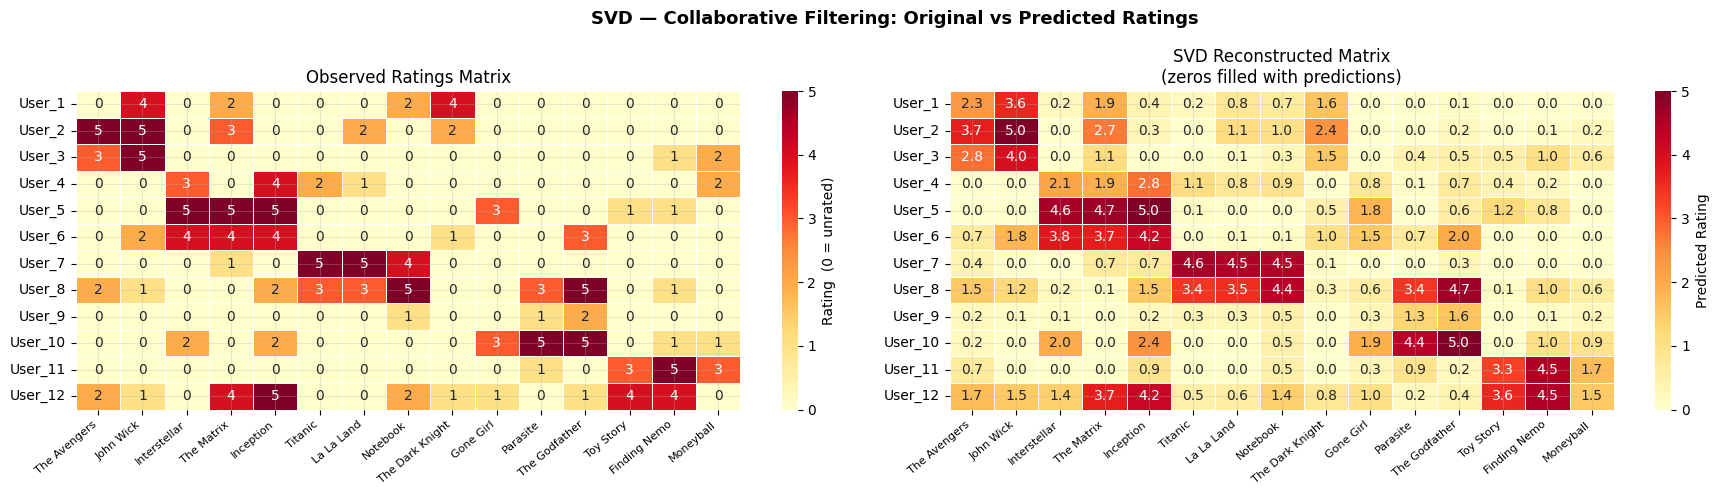

In [6]:
# ============================================================
# CELL 6 — TRUNCATED SVD | COLLABORATIVE FILTERING
# Dataset : Synthetic user-movie ratings matrix
# Task    : Predict ratings for unseen user-item pairs
# ============================================================

np.random.seed(42)

N_USERS  = 12
N_MOVIES = 15

MOVIE_GENRES = {
    'The Avengers':    'Action',   'John Wick':       'Action',
    'Interstellar':    'SciFi',    'The Matrix':      'SciFi',
    'Inception':       'SciFi',    'Titanic':         'Romance',
    'La La Land':      'Romance',  'Notebook':        'Romance',
    'The Dark Knight': 'Thriller', 'Gone Girl':       'Thriller',
    'Parasite':        'Drama',    'The Godfather':   'Drama',
    'Toy Story':       'Animated', 'Finding Nemo':    'Animated',
    'Moneyball':       'Sports',
}

movies = list(MOVIE_GENRES.keys())
users  = [f'User_{i + 1}' for i in range(N_USERS)]

# Genre preference map per user — drives synthetic rating generation
USER_PREFERENCES = [
    ['Action', 'Thriller'], ['Action', 'SciFi'],    ['Action'],
    ['SciFi'],              ['SciFi', 'Thriller'],   ['SciFi', 'Drama'],
    ['Romance'],            ['Romance', 'Drama'],    ['Thriller'],
    ['Drama', 'Thriller'],  ['Animated', 'Sports'],  ['Animated', 'SciFi'],
]

def build_ratings(n_users, movies, genre_map, prefs):
    """
    Simulate a sparse user-item matrix.
    Preferred genres: rated 3-5 with 75% observation probability.
    Non-preferred genres: rated 1-2 with 20% observation probability.
    """
    rng = np.random.default_rng(42)
    R   = np.zeros((n_users, len(movies)), dtype=float)
    for i, pref in enumerate(prefs):
        for j, movie in enumerate(movies):
            g = genre_map[movie]
            if g in pref:
                if rng.random() < 0.75:
                    R[i, j] = rng.integers(3, 6)
            else:
                if rng.random() < 0.20:
                    R[i, j] = rng.integers(1, 3)
    return R

ratings    = build_ratings(N_USERS, movies, MOVIE_GENRES, USER_PREFERENCES)
ratings_df = pd.DataFrame(ratings, index=users, columns=movies)

sparsity = (ratings == 0).sum() / ratings.size
print(f"Ratings matrix: {N_USERS} users x {N_MOVIES} movies")
print(f"Sparsity: {sparsity * 100:.1f}% of entries unrated (the problem we solve)")

# Truncated SVD: factorise R ~= U * Sigma * Vt
# U  : user latent factor matrix  (n_users x k)
# Vt : item latent factor matrix  (k x n_movies)
# k  : number of latent dimensions (tune for variance/noise trade-off)
N_COMPONENTS = 5
svd          = TruncatedSVD(n_components=N_COMPONENTS, random_state=42)
U            = svd.fit_transform(ratings)
Vt           = svd.components_

predicted    = np.clip(np.dot(U, Vt), 0, 5)
predicted_df = pd.DataFrame(predicted, index=users, columns=movies)

print(f"\nSVD latent factors : {N_COMPONENTS}")
print(f"Variance explained : {svd.explained_variance_ratio_.sum() * 100:.1f}%")

def get_recommendations(user, ratings_df, predicted_df, top_n=3):
    """Return top-N predicted ratings for items the user has not yet rated."""
    not_rated = ratings_df.loc[user][ratings_df.loc[user] == 0].index
    return predicted_df.loc[user, not_rated].sort_values(ascending=False).head(top_n)

print("\nTop recommendations per user:")
for user in ['User_1', 'User_4', 'User_7']:
    recs        = get_recommendations(user, ratings_df, predicted_df)
    liked_genres = list(set(
        MOVIE_GENRES[m] for m in movies if ratings_df.loc[user, m] >= 3
    ))
    print(f"\n  {user}  (liked genres: {liked_genres})")
    for movie, score in recs.items():
        print(f"    {movie:22s}  [{MOVIE_GENRES[movie]:10s}]  predicted rating: {score:.2f}/5")

# ── Visualisation ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 5))
fig.suptitle("SVD — Collaborative Filtering: Original vs Predicted Ratings",
             fontsize=13, fontweight='bold')

sns.heatmap(ratings_df, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.4, linecolor='white', ax=axes[0],
            cbar_kws={'label': 'Rating  (0 = unrated)'})
axes[0].set_title('Observed Ratings Matrix')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=40, ha='right', fontsize=8)

sns.heatmap(predicted_df.round(1), annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.4, linecolor='white', ax=axes[1],
            cbar_kws={'label': 'Predicted Rating'})
axes[1].set_title('SVD Reconstructed Matrix\n(zeros filled with predictions)')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=40, ha='right', fontsize=8)

plt.tight_layout()
plt.show()

# Notes:
# - SVD captures latent user and item factors (e.g. 'prefers action', 'is dramatic film')
# - Reconstruction fills unrated entries; recommendations = highest predicted scores
# - This is the foundational algorithm behind Netflix and Spotify recommendation engines

In [7]:
# ============================================================
# CELL 7 — PROJECT SUMMARY
# ============================================================

summary = {
    "1. Random Forest (Classification)": {
        "Dataset" : "Breast Cancer Wisconsin  |  569 samples, 30 features",
        "Task"    : "Malignant vs benign tumour classification",
        "Metrics" : "Accuracy, Precision, Recall, F1",
        "Output"  : "Confusion matrix + feature importance chart",
    },
    "2. Gradient Boosting (Regression)": {
        "Dataset" : "California Housing  |  20,640 samples, 8 features",
        "Task"    : "Median house price prediction",
        "Metrics" : "RMSE, R2 Score",
        "Output"  : "Actual vs predicted scatter + feature importance",
    },
    "3. KMeans + PCA (Clustering)": {
        "Dataset" : "Iris Flowers  |  150 samples, 4 features",
        "Task"    : "Unsupervised grouping without labels",
        "Metrics" : "Inertia (WCSS), Silhouette Score",
        "Output"  : "Elbow plot + PCA scatter + centroid heatmap",
    },
    "4. TF-IDF + Naive Bayes (NLP)": {
        "Dataset" : "20 Newsgroups  |  medicine, baseball, graphics",
        "Task"    : "Multi-class news article classification",
        "Metrics" : "Accuracy, F1, Classification Report",
        "Output"  : "Confusion matrix + top discriminative terms per class",
    },
    "5. SVD (Recommendations)": {
        "Dataset" : "Synthetic ratings matrix  |  12 users, 15 movies",
        "Task"    : "Predict ratings for unseen user-item pairs",
        "Metrics" : "Predicted rating, variance explained",
        "Output"  : "Observed vs reconstructed ratings heatmap",
    },
}

divider = "-" * 60
print("\n" + "=" * 60)
print("  ML PLAYGROUND — COMPLETE")
print("=" * 60)

for algo, details in summary.items():
    print(f"\n{divider}")
    print(f"  {algo}")
    for k, v in details.items():
        print(f"    {k:10s}: {v}")

print(f"\n{divider}")
print("  Stack : scikit-learn, pandas, NumPy, matplotlib, seaborn")
print("  Author: Kunal Vivek Soyane  |  github.com/KunalSoyane")
print("=" * 60)


  ML PLAYGROUND — COMPLETE

------------------------------------------------------------
  1. Random Forest (Classification)
    Dataset   : Breast Cancer Wisconsin  |  569 samples, 30 features
    Task      : Malignant vs benign tumour classification
    Metrics   : Accuracy, Precision, Recall, F1
    Output    : Confusion matrix + feature importance chart

------------------------------------------------------------
  2. Gradient Boosting (Regression)
    Dataset   : California Housing  |  20,640 samples, 8 features
    Task      : Median house price prediction
    Metrics   : RMSE, R2 Score
    Output    : Actual vs predicted scatter + feature importance

------------------------------------------------------------
  3. KMeans + PCA (Clustering)
    Dataset   : Iris Flowers  |  150 samples, 4 features
    Task      : Unsupervised grouping without labels
    Metrics   : Inertia (WCSS), Silhouette Score
    Output    : Elbow plot + PCA scatter + centroid heatmap

--------------------